In [1]:
#import needed libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
#our basic area and price data -- training data
square_feet  = np.array([1000,1500,2000,2500,3000,3500]).reshape(-1,1)
prices = np.array([200000, 280000,350000,430000,500000,580000])

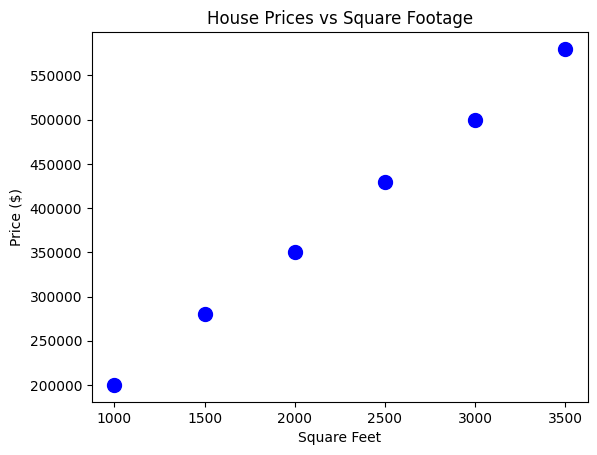

In [ ]:
#data visualization -- Exploratory Data Analysis (EDA)
plt.scatter(square_feet, prices, color = 'blue', s = 100)
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.title("House Prices vs Square Footage")
plt.show()

In [ ]:
#create and train a regression model
model = LinearRegression()
model.fit(square_feet,prices)

LinearRegression()

In [ ]:
# Look at what our model predicts for the given data
predicted_prices = model.predict(square_feet)
for area,p_price, price in zip(square_feet,predicted_prices,prices):
  print(f"Home area: {area[0]}ft^2 Predicted Price: ${p_price:,.0f} Actual Price: ${price:,}")

Home area: 1000ft^2 Predicted Price: $201,429 Actual Price: $200,000
Home area: 1500ft^2 Predicted Price: $276,857 Actual Price: $280,000
Home area: 2000ft^2 Predicted Price: $352,286 Actual Price: $350,000
Home area: 2500ft^2 Predicted Price: $427,714 Actual Price: $430,000
Home area: 3000ft^2 Predicted Price: $503,143 Actual Price: $500,000
Home area: 3500ft^2 Predicted Price: $578,571 Actual Price: $580,000


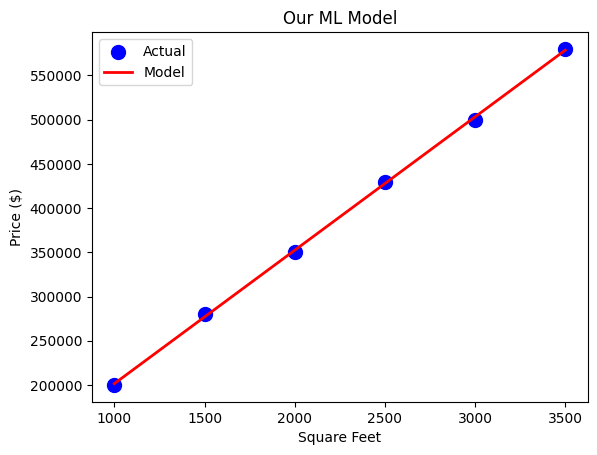

In [ ]:
#visualize the model
plt.scatter(square_feet, prices, color='blue', s=100, label='Actual')
plt.plot(square_feet, predicted_prices, color='red', linewidth=2, label='Model')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Our ML Model')
plt.legend()
plt.show()

In [ ]:
#make predictions for a new house of 2750
new_house = np.array([[2750]])
predicted = model.predict(new_house)
print(f"Predicted price for 2750 sq ft house: ${predicted[0]:,.0f}")

Predicted price for 2750 sq ft house: $465,429


In [ ]:
# view and consider what the model learned -- is this a highly "interpretable" model?
print(f"The model learned: Price = ${model.coef_[0]:.2f} x square feet + ${model.intercept_:.2f}")

The model learned: Price = $150.86 x square feet + $50571.43


In [ ]:
#calculate how wrong we are
errors = prices - predicted_prices
for i, (sf, actual, pred, err) in enumerate(zip(square_feet, prices, predicted_prices, errors)):
    print(f"House {i+1}: {sf[0]} sq ft - Actual: ${actual:,}, Predicted: ${pred:,.0f}, Error: ${err:,.0f}")

House 1: 1000 sq ft - Actual: $200,000, Predicted: $201,429, Error: $-1,429
House 2: 1500 sq ft - Actual: $280,000, Predicted: $276,857, Error: $3,143
House 3: 2000 sq ft - Actual: $350,000, Predicted: $352,286, Error: $-2,286
House 4: 2500 sq ft - Actual: $430,000, Predicted: $427,714, Error: $2,286
House 5: 3000 sq ft - Actual: $500,000, Predicted: $503,143, Error: $-3,143
House 6: 3500 sq ft - Actual: $580,000, Predicted: $578,571, Error: $1,429


In [ ]:
#calculate the mean squared error (MSE)
mse = np.mean(errors**2)
print(f"Mean Squared Error: ${mse:,.0f}")


Mean Squared Error: $5,714,286


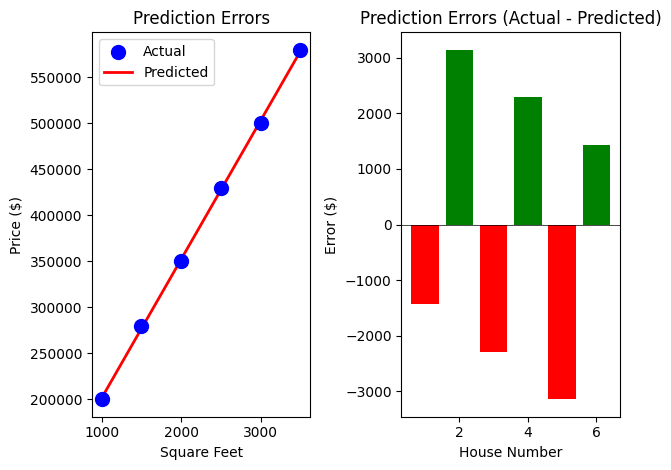

In [ ]:
#visualize errors
plt.subplot(1, 2, 1)
plt.scatter(square_feet, prices, color='blue', s=100, label='Actual', zorder=3)
plt.plot(square_feet, predicted_prices, color='red', linewidth=2, label='Predicted')
# Draw error lines
for sf, actual, pred in zip(square_feet, prices, predicted_prices):
    plt.plot([sf[0], sf[0]], [actual, pred], 'k--', alpha=0.5, linewidth=3)
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Prediction Errors')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(1, len(errors)+1), errors, color=['red' if e < 0 else 'green' for e in errors])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('House Number')
plt.ylabel('Error ($)')
plt.title('Prediction Errors (Actual - Predicted)')
plt.tight_layout()
plt.show()

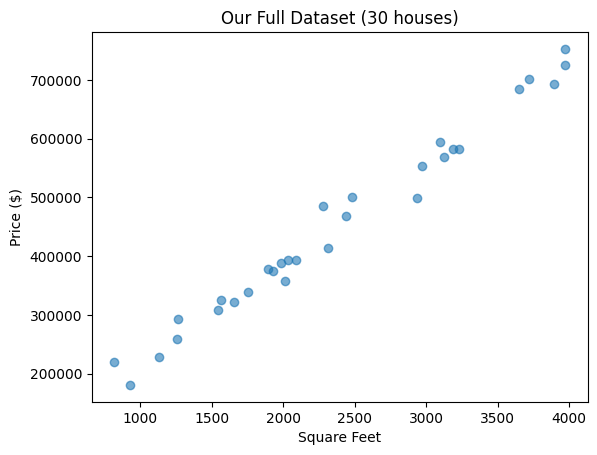

Training set: 21 houses
Testing set: 9 houses

Training MSE: $350,160,806
Testing MSE: $727,503,245


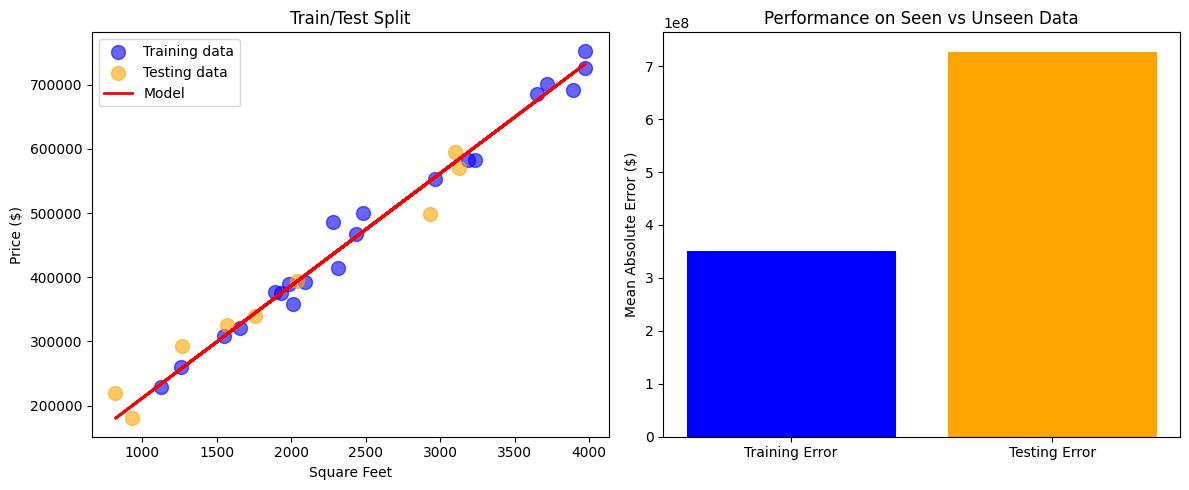

In [2]:
# Let's get more data (simulated for demo purposes)
np.random.seed(42)
all_square_feet = np.random.randint(800, 4000, size=30).reshape(-1, 1)
# True relationship with some noise
all_prices = 170 * all_square_feet.flatten() + 50000 + np.random.normal(0, 25000, size=30)

# Visualize all our data
plt.scatter(all_square_feet, all_prices, alpha=0.6)
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Our Full Dataset (30 houses)')
plt.show()

# Split into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    all_square_feet, all_prices, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} houses")
print(f"Testing set: {len(X_test)} houses")

# Train on training data only
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate on both sets
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mse = np.mean((y_train - train_predictions)**2)
test_mse = np.mean((y_test - test_predictions)**2)

print(f"\nTraining MSE: ${train_mse:,.0f}")
print(f"Testing MSE: ${test_mse:,.0f}")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', s=100, alpha=0.6, label='Training data')
plt.scatter(X_test, y_test, color='orange', s=100, alpha=0.6, label='Testing data')
plt.plot(all_square_feet, model.predict(all_square_feet), 'r-', linewidth=2, label='Model')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Train/Test Split')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['Training Error', 'Testing Error'], [train_mse, test_mse], color=['blue', 'orange'])
plt.ylabel('Mean Absolute Error ($)')
plt.title('Performance on Seen vs Unseen Data')
plt.tight_layout()
plt.show()

In [3]:
# Now with multiple features
# Square feet, bedrooms, age (years)
X_multi = np.array([
    [1000, 2, 30],
    [1500, 3, 20],
    [2000, 3, 10],
    [2500, 4, 5],
    [3000, 4, 2],
    [3500, 5, 1]
])
prices = np.array([200000, 280000, 350000, 430000, 500000, 580000])

# Train model
model_multi = LinearRegression()
model_multi.fit(X_multi, prices)

# See what it learned
print("Model equation:")
print(f"Price = ${model_multi.intercept_:,.0f}")
print(f"  + ${model_multi.coef_[0]:.2f} × square_feet")
print(f"  + ${model_multi.coef_[1]:,.0f} × bedrooms")
print(f"  + ${model_multi.coef_[2]:,.0f} × age")

# Make prediction
new_house = np.array([[2200, 3, 15]])  # 2200 sq ft, 3 bed, 15 years old
prediction = model_multi.predict(new_house)
print(f"\nPredicted price for 2200 sq ft, 3 bed, 15-year-old house: ${prediction[0]:,.0f}")

# Compare to single feature
single_feature_pred = model.predict(np.array([[2200]]))
print(single_feature_pred)
print(f"Single feature model would predict: ${single_feature_pred[0]:,.0f}")
print(f"Difference: ${abs(prediction[0] - single_feature_pred[0]):,.0f}")

Model equation:
Price = $40,000
  + $140.00 × square_feet
  + $10,000 × bedrooms
  + $-0 × age

Predicted price for 2200 sq ft, 3 bed, 15-year-old house: $378,000
[421675.54787199]
Single feature model would predict: $421,676
Difference: $43,676


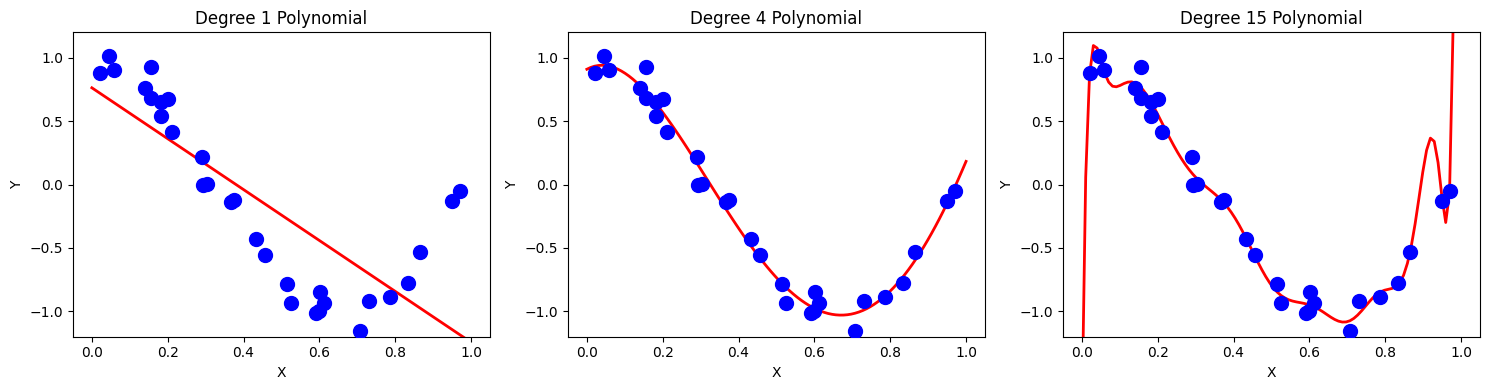

Notice:
- Degree 1: Simple line, might miss pattern
- Degree 4: Smooth curve, captures trend
- Degree 15: Wild curve, goes through every point but looks crazy!

This is overfitting - too complex, memorizes noise


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

#Generate a small, noisy dataset
np.random.seed(42)
n_samples = 30
# The true function is a cosine wave: y = cos(1.5 * pi * x) + noise
true_fun = lambda X: np.cos(1.5 * np.pi * X)
X = np.sort(np.random.rand(n_samples)).reshape(-1,1)
y = true_fun(X).flatten() + np.random.randn(n_samples) * 0.1


# Compare different polynomial degrees
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 4, 15]):
    plt.subplot(1, 3, i+1)

    # Fit model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)

    # Plot
    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.scatter(X, y, color='blue', s=100, zorder=3)
    plt.plot(X_plot, y_plot, 'r-', linewidth=2)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Degree {degree} Polynomial')
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("Notice:")
print("- Degree 1: Simple line, might miss pattern")
print("- Degree 4: Smooth curve, captures trend")
print("- Degree 15: Wild curve, goes through every point but looks crazy!")
print("\nThis is overfitting - too complex, memorizes noise")